In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# Test con aspirina
mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
print("RDKit funziona:", mol is not None)
print("Peso molecolare aspirina:", Descriptors.MolWt(mol))

RDKit funziona: True
Peso molecolare aspirina: 180.15899999999996


In [2]:
!pip install chembl_webresource_client


In [3]:
import pandas as pd

In [4]:
from chembl_webresource_client.new_client import new_client


target = new_client.target
target_query = target.search('EGFR')
targets_df = pd.DataFrame.from_dict(target_query)
targets_df[['target_chembl_id', 'pref_name', 'organism', 'target_type']].head(10)

,target_chembl_id,pref_name,organism,target_type
0,CHEMBL4523747,EGFR/PPP1CA,Homo sapiens,PROTEIN-PROTEIN INTERACTION
1,CHEMBL5465557,CCN2-EGFR,Homo sapiens,PROTEIN-PROTEIN INTERACTION
2,CHEMBL3608,Epidermal growth factor receptor,Mus musculus,SINGLE PROTEIN
3,CHEMBL6193842,Protein cereblon/Epidermal growth factor receptor,Mus musculus,PROTEIN-PROTEIN INTERACTION
4,CHEMBL203,Epidermal growth factor receptor,Homo sapiens,SINGLE PROTEIN
5,CHEMBL4523680,Protein cereblon/Epidermal growth factor receptor,Homo sapiens,PROTEIN-PROTEIN INTERACTION
6,CHEMBL2363049,Epidermal growth factor receptor,Homo sapiens,PROTEIN FAMILY
7,CHEMBL3137284,MER intracellular domain/EGFR extracellular do...,Homo sapiens,CHIMERIC PROTEIN
8,CHEMBL4523998,von Hippel-Lindau disease tumor suppressor/Epi...,Homo sapiens,PROTEIN-PROTEIN INTERACTION
9,CHEMBL6193841,Protein cereblon/Epidermal growth factor receptor,Mus musculus,PROTEIN-PROTEIN INTERACTION


In [8]:
activity = new_client.activity
res = activity.filter(
    target_chembl_id='CHEMBL203',
    standard_type="IC50",
    standard_units="nM"
).only([
    'molecule_chembl_id', 'canonical_smiles', 'standard_value',
    'standard_units', 'standard_type'
])

df_activity = pd.DataFrame.from_dict(res)
print("Shape:", df_activity.shape)
df_activity.head()

Shape: (25244, 8)


,canonical_smiles,molecule_chembl_id,standard_type,standard_units,standard_value,type,units,value
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,IC50,nM,41.0,IC50,uM,0.041
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,IC50,nM,300.0,IC50,uM,0.3
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,IC50,nM,7820.0,IC50,uM,7.82
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,IC50,nM,170.0,IC50,uM,0.17
4,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,IC50,nM,40.0,IC50,uM,0.04


In [11]:
df_activity.to_csv("data/egfr_raw_activity.csv", index=False)
print(f"saved {df_activity.shape[0]} rows, {df_activity['molecule_chembl_id'].nunique()} unique molecule")

Salvato: 25244 righe, 13698 molecole uniche


In [14]:
# standard_value to numeric / removing NaN
df_activity['standard_value'] = pd.to_numeric(df_activity['standard_value'], errors='coerce')
df_activity = df_activity.dropna(subset=['standard_value', 'canonical_smiles'])

# IC50 median 
df_clean = df_activity.groupby(['molecule_chembl_id', 'canonical_smiles'])['standard_value'].median().reset_index()
df_clean.columns = ['molecule_chembl_id', 'canonical_smiles', 'IC50_nM']

print("total molecule:", df_clean.shape[0])
df_clean.head()

total molecule: 13577


,molecule_chembl_id,canonical_smiles,IC50_nM
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,33000.0
1,CHEMBL100714,COc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1OC,2800.0
2,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,451440.0
3,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,10000.0
4,CHEMBL101581,COc1cc2nccc(Oc3cccc(Br)c3)c2cc1OC,2500.0


In [18]:
import matplotlib.pyplot as plt

count    1.357700e+04
mean     7.627358e+05
std      1.596078e+07
min      5.012000e-09
25%      2.300000e+01
50%      1.840000e+02
75%      3.800000e+03
max      3.971678e+08
Name: IC50_nM, dtype: float64

pIC50 (log-transformed) stats:
count    13577.000000
mean         6.603092
std          1.450620
min          0.401026
25%          5.420216
50%          6.735182
75%          7.638272
max         17.299989
Name: pIC50, dtype: float64


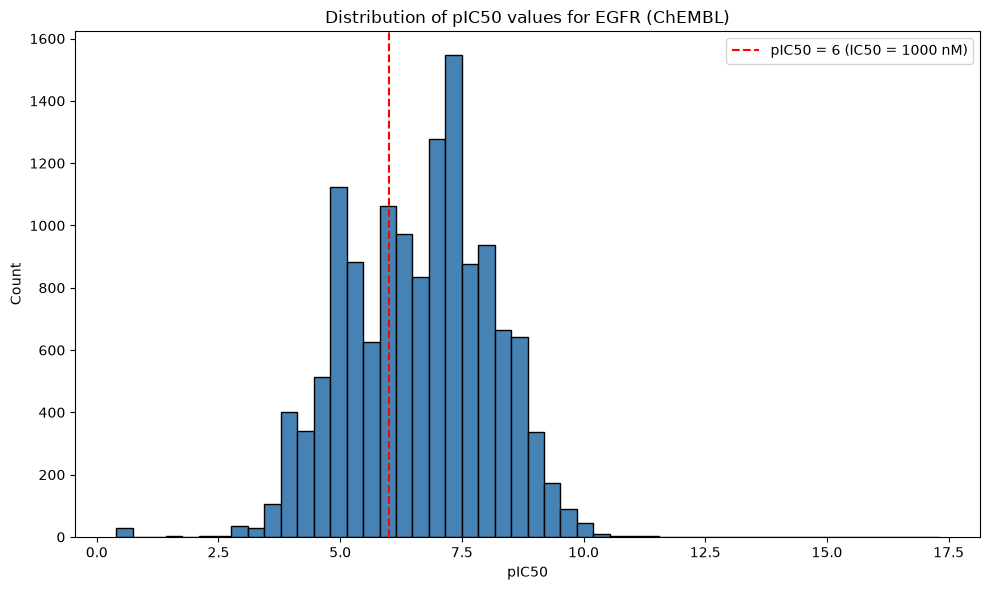

In [20]:
import numpy as np

# Log-transform IC50 for distribution inspection 
df_clean['pIC50'] = -np.log10(df_clean['IC50_nM'] * 1e-9)  # convert nM to M, then -log10

print(df_clean['IC50_nM'].describe())
print("\npIC50 (log-transformed) stats:")
print(df_clean['pIC50'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df_clean['pIC50'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(6, color='red', linestyle='--', label='pIC50 = 6 (IC50 = 1000 nM)')
plt.xlabel('pIC50')
plt.ylabel('Count')
plt.title('Distribution of pIC50 values for EGFR (ChEMBL)')
plt.legend()
plt.tight_layout()
plt.savefig('results/plots/pIC50_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# IC50 values below 0.01 nM (10 pM) are biologically implausible for
# small-molecule inhibitors and likely reflect data entry/unit errors.
# Similarly cap the upper bound to remove extreme inactive outliers.
df_clean = df_clean[(df_clean['IC50_nM'] >= 0.01) & (df_clean['IC50_nM'] <= 1e6)]

print("Molecules after outlier filtering:", df_clean.shape[0])

# Define active/inactive label using the standard IC50 = 1000 nM threshold
# (pIC50 = 6), which aligns with the median of this dataset.
df_clean['label'] = (df_clean['IC50_nM'] < 1000).astype(int)

print("\nClass distribution:")
print(df_clean['label'].value_counts())
print(f"\nActive fraction: {df_clean['label'].mean():.1%}")

Molecules after outlier filtering: 13518

Class distribution:
label
1    8715
0    4803
Name: count, dtype: int64

Active fraction: 64.5%


In [24]:
df_clean.to_csv("data/egfr_clean_dataset.csv", index=False)
print(f"Saved: {df_clean.shape[0]} molecules ({df_clean['label'].sum()} active, {(df_clean['label']==0).sum()} inactive)")

Saved: 13518 molecules (8715 active, 4803 inactive)


## Dataset Construction — Summary

Bioactivity data for EGFR (ChEMBL target ID: CHEMBL203, Homo sapiens,
SINGLE PROTEIN) was retrieved from ChEMBL via the REST API, filtered
to standardized IC50 measurements in nM.   
**Pipeline:**
1. Retrieved 25,244 raw IC50 bioactivity records for EGFR
2. Aggregated multiple measurements per molecule using the median
   IC50 value, reducing to 13,698 unique molecules
3. Filtered biologically implausible outliers (IC50 < 0.01 nM or > 1,000,000 nM), retaining 13,518 molecules
4. Applied the standard activity threshold (IC50 < 1000 nM = active),
   consistent with the pIC50 = 6 cutoff commonly used in
   drug discovery and aligned with the median of this dataset
   (pIC50 = 6.74)

**Final dataset**: 13,518 molecules — 8,715 active (64.5%), 4,803
inactive (35.5%)

This dataset will be used in the next notebook to generate molecular
fingerprints (RDKit) and train classification models to distinguish
active from inactive EGFR inhibitors.